In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
start = '2016-01-01'
end = '2026-04-01'
stock = 'GOOG'

data = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [3]:
data.reset_index(inplace=True)

In [4]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2016-01-04,36.789955,36.900051,36.265165,36.847485,65456000
1,2016-01-05,36.826656,37.293818,36.631258,37.018577,39014000
2,2016-01-06,36.878231,37.054783,36.149216,36.202777,38940000
3,2016-01-07,36.023746,36.624315,35.660230,36.218150,59274000
4,2016-01-08,35.432602,36.362963,35.359703,36.274688,49018000
...,...,...,...,...,...,...
2570,2026-03-25,289.589996,294.660004,287.369995,292.149994,22343000
2571,2026-03-26,280.739990,286.515015,279.049988,286.190002,29281200
2572,2026-03-27,273.760010,279.089996,273.480011,277.399994,25703300


In [5]:
ma_100_days = data.Close.rolling(100).mean()

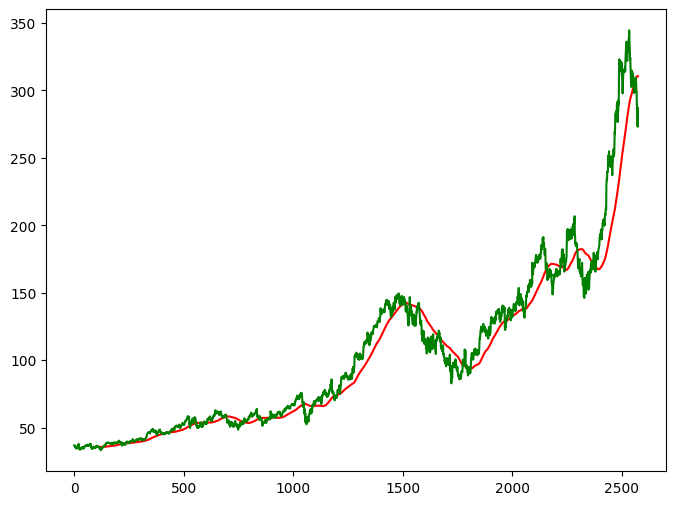

In [6]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(data.Close, 'g')
plt.show()

In [7]:
ma_200_days = data.Close.rolling(200).mean()

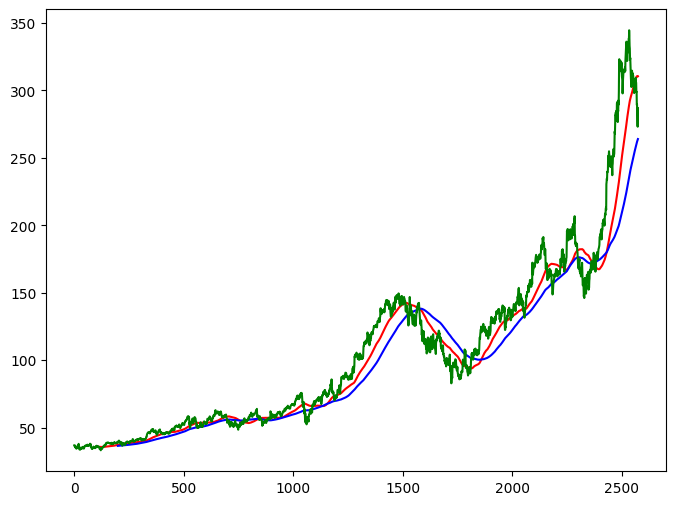

In [8]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(ma_200_days,'b')
plt.plot(data.Close,'g')
plt.show()

In [9]:
data.dropna(inplace=True)

In [10]:
data_train = pd.DataFrame(data.Close[0: int(len(data)*0.80)])
data_test = pd.DataFrame(data.Close[int(len(data)*0.80): len(data)])

In [11]:
data_train.shape[0]

2060

In [12]:
data_test.shape[0]

515

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [14]:
data_train_scale = scaler.fit_transform(data_train)

In [15]:
x = []
y = []

for i in range(100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])
    

In [16]:
x, y = np.array(x), np.array(y)

In [17]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [18]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True,
               input_shape = ((x.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation='relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units =1))

In [19]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [20]:
model.fit(x,y, epochs = 50, batch_size =32, verbose =1)

Epoch 1/50
62/62 [==============================] - 19s 201ms/step - loss: 0.0484
Epoch 2/50
62/62 [==============================] - 14s 225ms/step - loss: 0.0093
Epoch 3/50
62/62 [==============================] - 15s 242ms/step - loss: 0.0081
Epoch 4/50
62/62 [==============================] - 14s 219ms/step - loss: 0.0082
Epoch 5/50
62/62 [==============================] - 15s 236ms/step - loss: 0.0065
Epoch 6/50
62/62 [==============================] - 14s 219ms/step - loss: 0.0075
Epoch 7/50
62/62 [==============================] - 15s 239ms/step - loss: 0.0065
Epoch 8/50
62/62 [==============================] - 15s 245ms/step - loss: 0.0064
Epoch 9/50
62/62 [==============================] - 14s 223ms/step - loss: 0.0065
Epoch 10/50
62/62 [==============================] - 14s 226ms/step - loss: 0.0064
Epoch 11/50
62/62 [==============================] - 18s 297ms/step - loss: 0.0061
Epoch 12/50
62/62 [==============================] - 14s 220ms/step - loss: 0.0062
Epoch 13/50
6

In [21]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 100, 50)           10400     
                                                                 
 dropout (Dropout)           (None, 100, 50)           0         
                                                                 
 lstm_1 (LSTM)               (None, 100, 60)           26640     
                                                                 
 dropout_1 (Dropout)         (None, 100, 60)           0         
                                                                 
 lstm_2 (LSTM)               (None, 100, 80)           45120     
                                                                 
 dropout_2 (Dropout)         (None, 100, 80)           0         
                                                                 
 lstm_3 (LSTM)               (None, 120)               9

In [22]:
pas_100_days = data_train.tail(100)

In [23]:
data_test = pd.concat([pas_100_days, data_test], ignore_index=True)

In [24]:
data_test_scale  =  scaler.fit_transform(data_test)

In [25]:
x = []
y = []

for i in range(100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])
x, y = np.array(x), np.array(y)

In [26]:
y_predict = model.predict(x)

17/17 [==============================] - 4s 119ms/step


In [27]:
scale =1/scaler.scale_

In [28]:
y_predict = y_predict*scale

In [29]:
y = y*scale

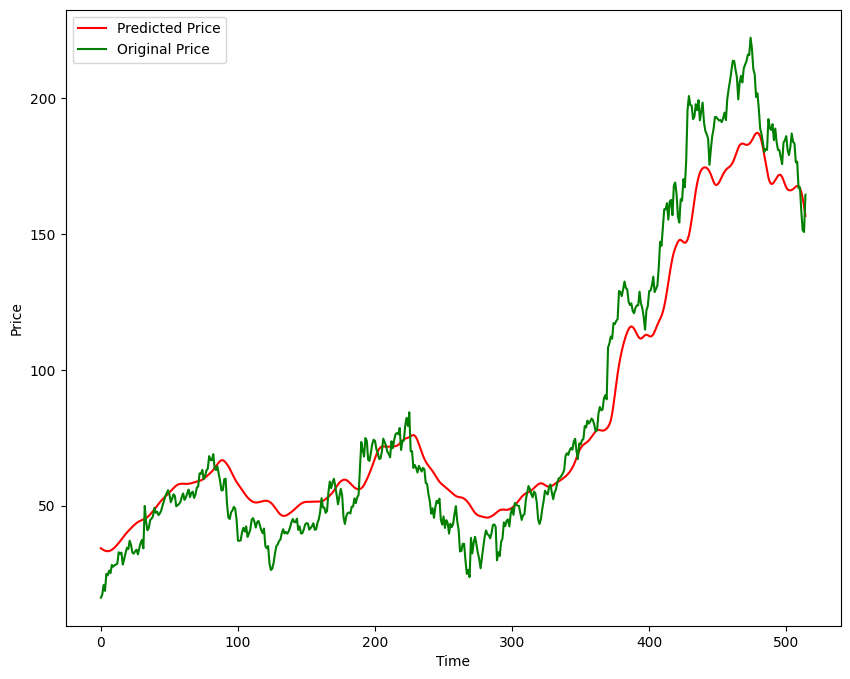

In [30]:
plt.figure(figsize=(10,8))
plt.plot(y_predict, 'r', label = 'Predicted Price')
plt.plot(y, 'g', label = 'Original Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [31]:
model.save('Stock Predictions Model.keras')